# Minor Project 7 - KNN and Naive Bayes


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

## Classification

## Import Dataset

In [ ]:
df = pd.read_csv("/content/framingham.csv")

## Initial Analysis

In [ ]:
print(df.head())

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB
None


In [ ]:
print(df.describe())

              male          age    education  currentSmoker   cigsPerDay  \
count  4238.000000  4238.000000  4133.000000    4238.000000  4209.000000   
mean      0.429212    49.584946     1.978950       0.494101     9.003089   
std       0.495022     8.572160     1.019791       0.500024    11.920094   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  4185.000000      4238.000000   4238.000000  4238.000000  4188.000000   
mean      0.029630         0.005899      0.310524     0.025720   236.721585   
std       0.169584         0.076587      0.462763     0.158316    44.590334   

## Check for Duplicates

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB
None



## Outlier Detection and Correction






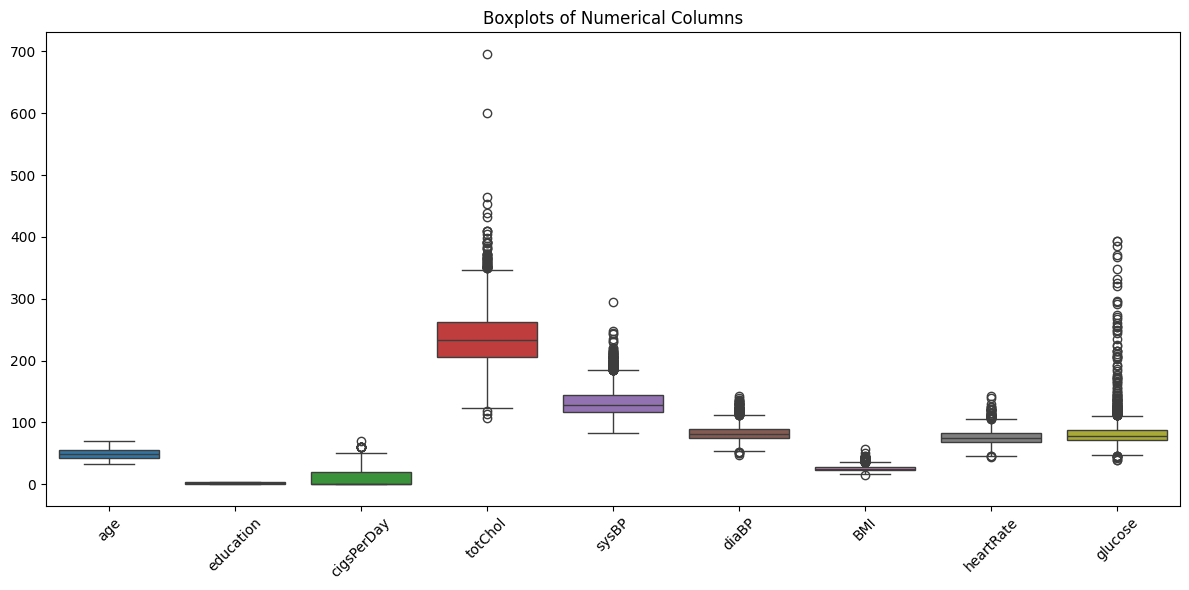

In [ ]:
num_cols = df.select_dtypes(include = ["float64", "int64"]).columns.tolist()
bool_cols = [col for col in num_cols if set(df[col].unique()) <= {0, 1}]

num_cols = [col for col in num_cols if col not in bool_cols]

if 'BPMeds' in num_cols:
    num_cols.remove('BPMeds')

plt.figure(figsize = (12, 6))
sns.boxplot(data = df[num_cols])
plt.xticks(rotation = 45)
plt.title("Boxplots of Numerical Columns")
plt.tight_layout()
plt.show()


In [ ]:
def outlier_correction(df, col, show_plot = True):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

    return df

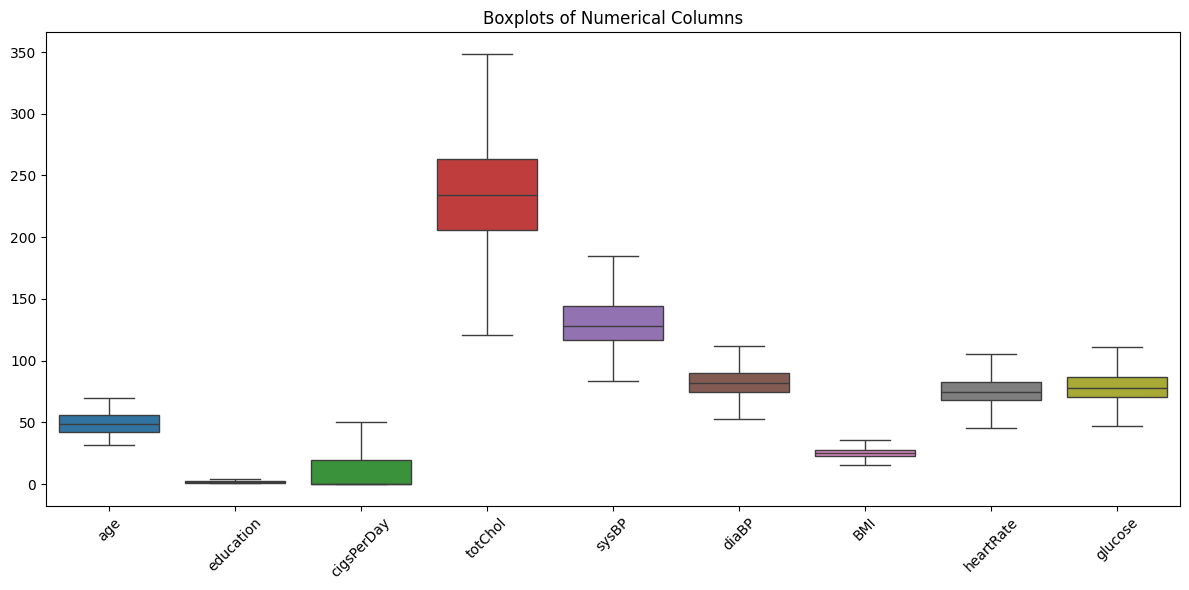

In [ ]:
for col in num_cols:
    df = outlier_correction(df, col, show_plot = False)
plt.figure(figsize = (12, 6))
sns.boxplot(data = df[num_cols])
plt.xticks(rotation = 45)
plt.title("Boxplots of Numerical Columns")
plt.tight_layout()
plt.show()

## Handling Missing Values

In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ["float64", "int64"]:
            df[col].fillna(df[col].mean(), inplace = True)
        else:
            df[col].fillna(df[col].mode()[0], inplace = True)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   float64
 2   education        4238 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4238 non-null   float64
 5   BPMeds           4238 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4238 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4238 non-null   float64
 13  heartRate        4238 non-null   float64
 14  glucose          4238 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(10), int64(6)
memory usage: 529.9 KB
None


## Bivariate Analysis

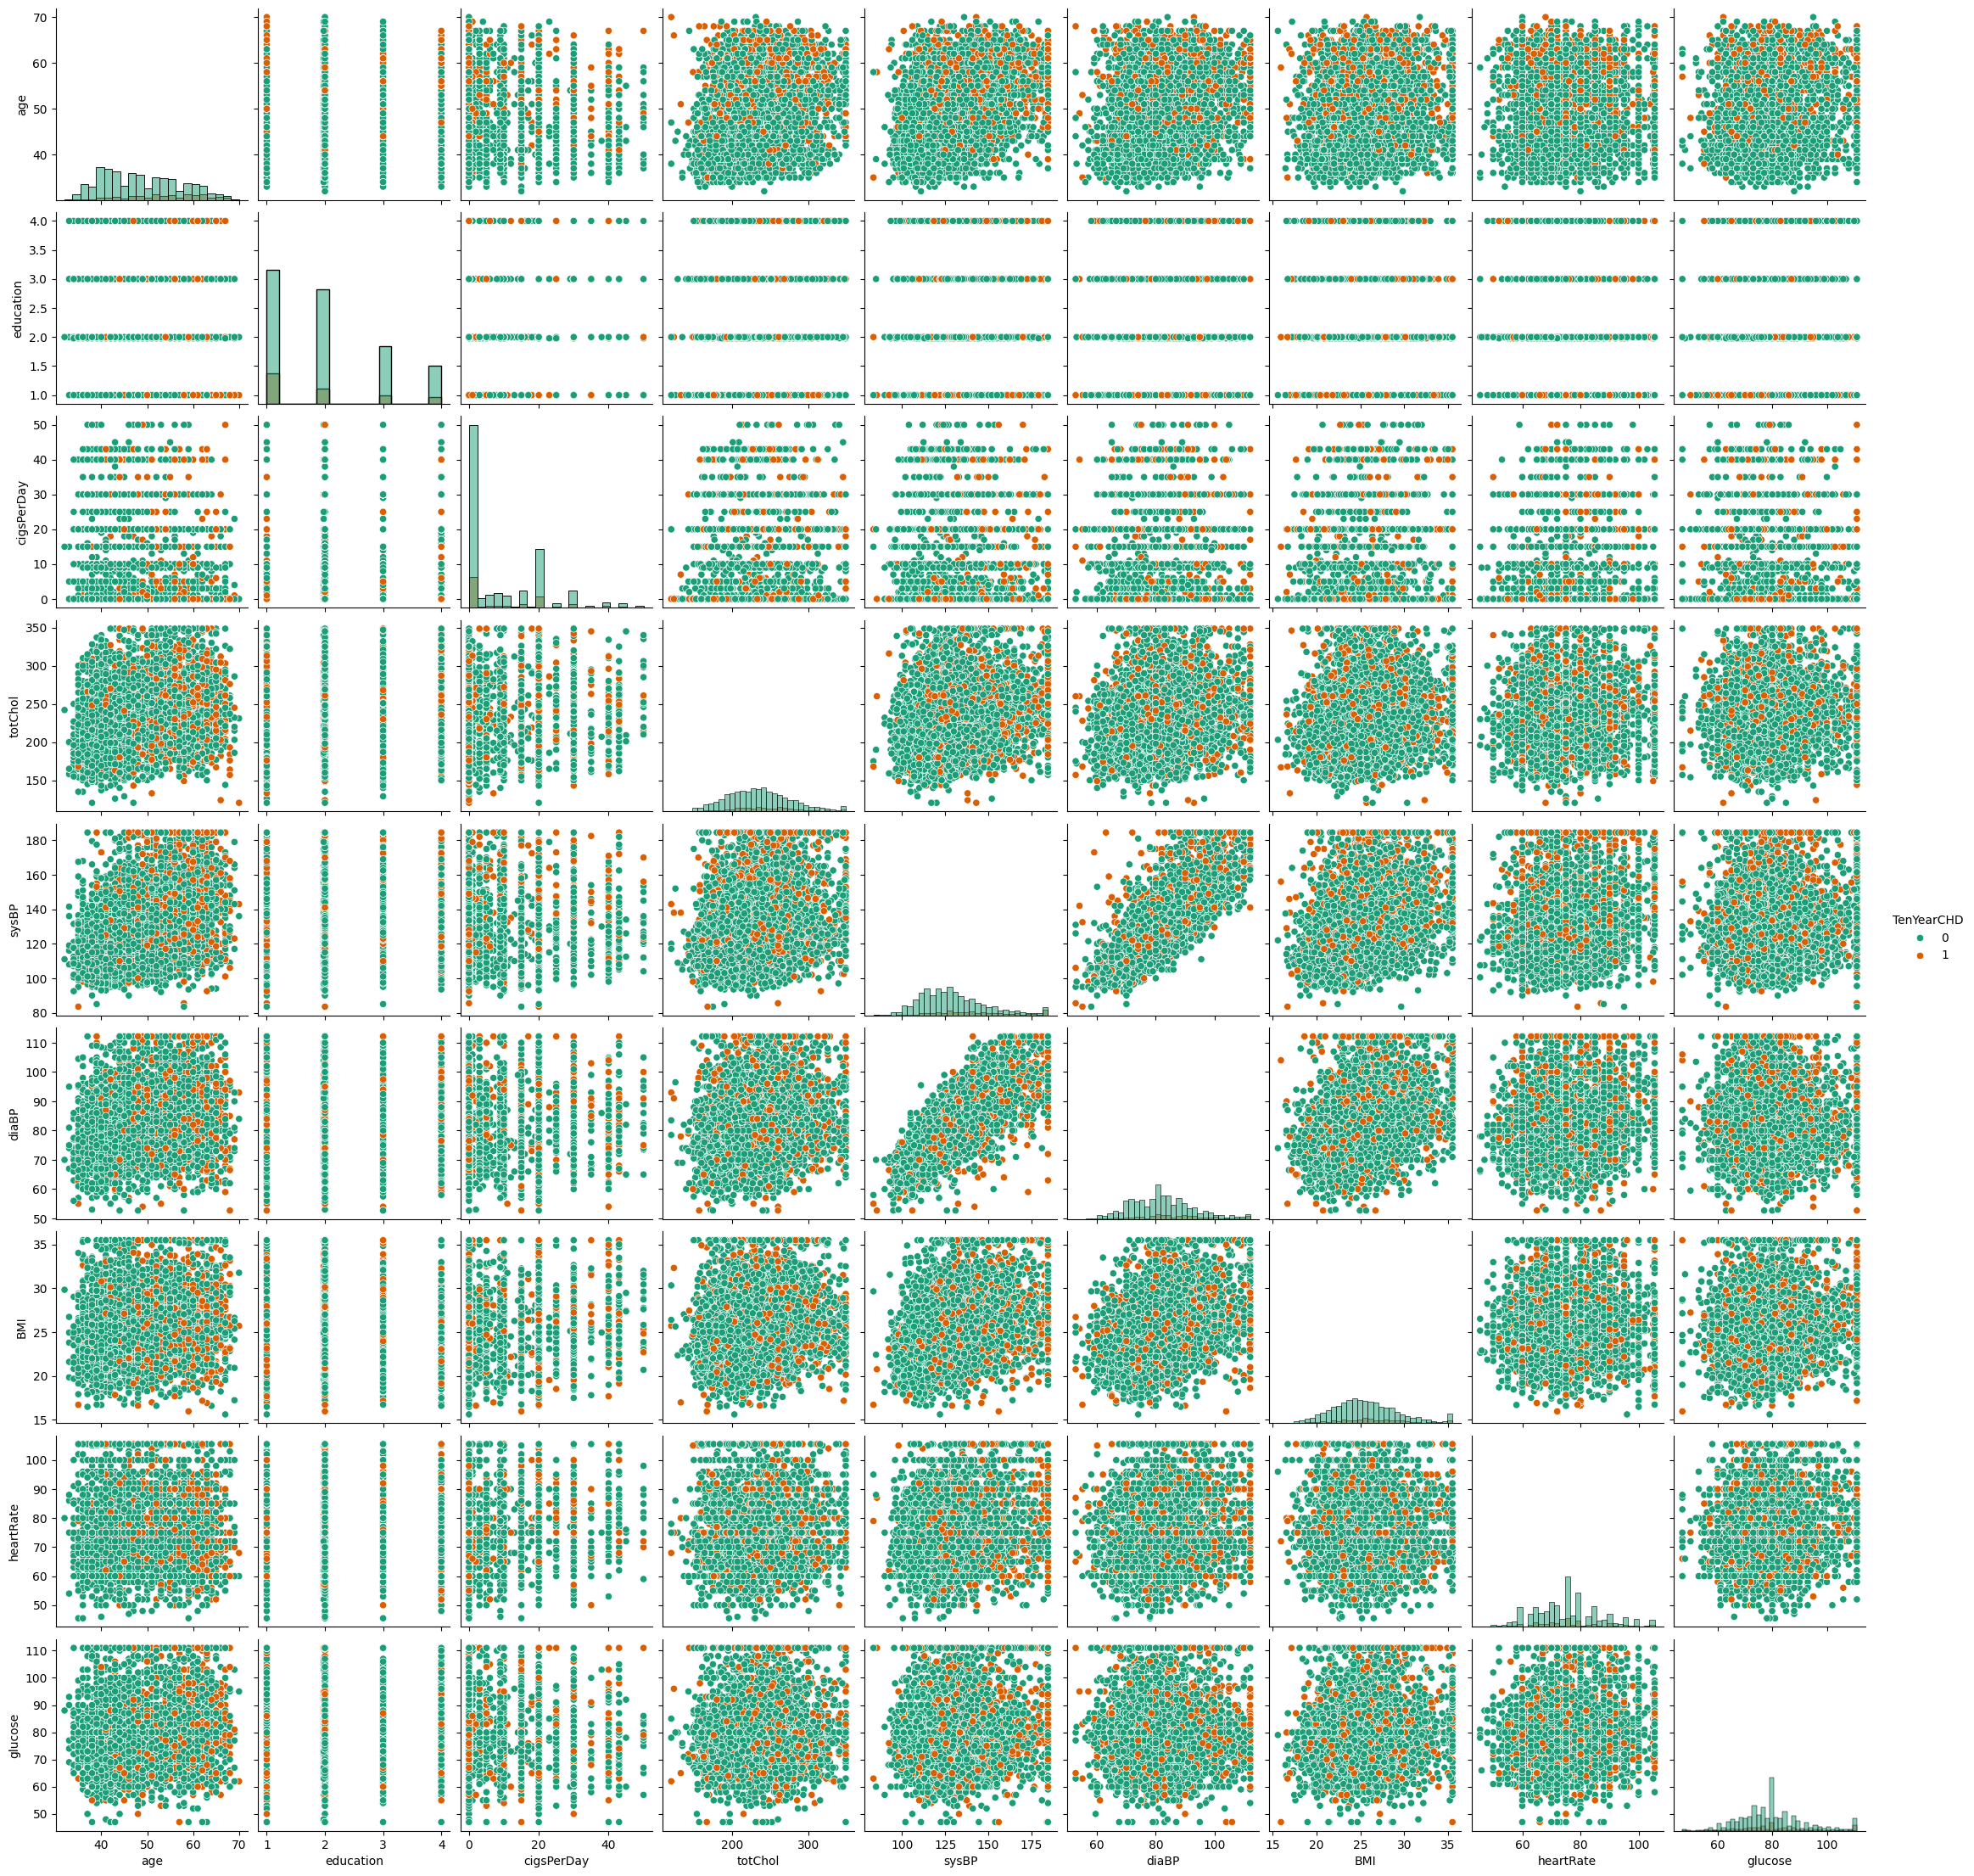

In [ ]:
cols_for_pairplot = [col for col in num_cols if col != 'TenYearCHD'] + ['TenYearCHD']

sns.pairplot(df[cols_for_pairplot], hue = 'TenYearCHD', palette = 'Dark2', diag_kind = 'hist')
plt.show()


## Correlation and Heatmap

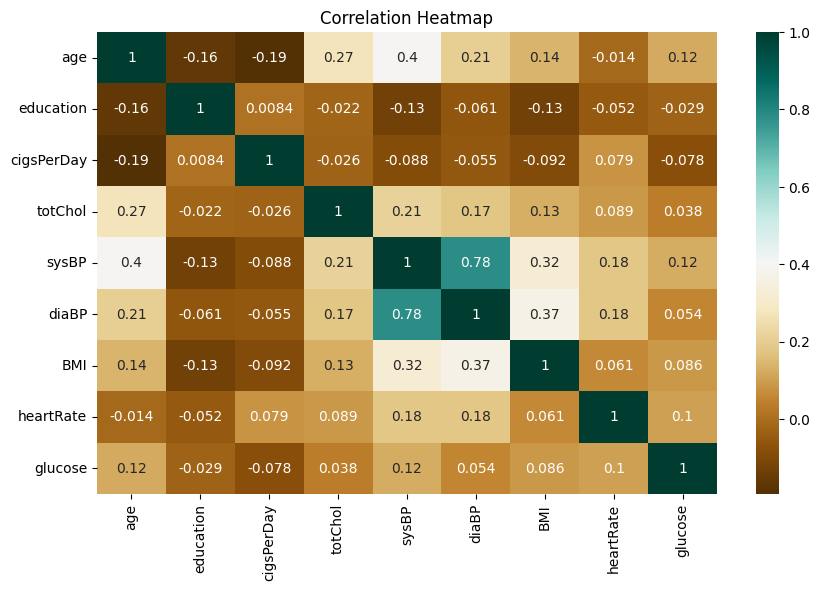

In [ ]:
plt.figure(figsize = (10,6))
sns.heatmap(df[num_cols].corr(), annot = True, cmap = "BrBG")
plt.title("Correlation Heatmap")
plt.show()

## Normalisation and Scaling

In [ ]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


print(df.head())

   male       age  education  currentSmoker  cigsPerDay  BPMeds  \
0     1 -1.234951   2.007088              0   -0.763176     0.0   
1     0 -0.418257   0.020905              0   -0.763176     0.0   
2     1 -0.184916  -0.972187              1    0.938026     0.0   
3     0  1.331800   1.013996              1    1.788627     0.0   
4     0 -0.418257   1.013996              1    1.193206     0.0   

   prevalentStroke  prevalentHyp  diabetes   totChol     sysBP     diaBP  \
0                0             0         0 -0.973368 -1.255196 -1.118089   
1                0             0         0  0.324501 -0.528621 -0.152197   
2                0             0         0  0.206513 -0.213772 -0.240006   
3                0             1         0 -0.265439  0.876090  1.077119   
4                0             0         0  1.150418 -0.092676  0.111228   

        BMI  heartRate   glucose  TenYearCHD  
0  0.330564   0.365620 -0.239238           0  
1  0.795016   1.656276 -0.320951           0  

## Train Test Split

In [ ]:
X = df.drop('TenYearCHD', axis = 1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## KNN

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_train = model.predict(X_train)
print("Accuracy Score:",accuracy_score(y_train, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("Classification Report:\n", classification_report(y_train, y_pred_train))

Accuracy Score: 0.8693215339233038
Confusion Matrix:
 [[2844   31]
 [ 412  103]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      2875
           1       0.77      0.20      0.32       515

    accuracy                           0.87      3390
   macro avg       0.82      0.59      0.62      3390
weighted avg       0.86      0.87      0.84      3390



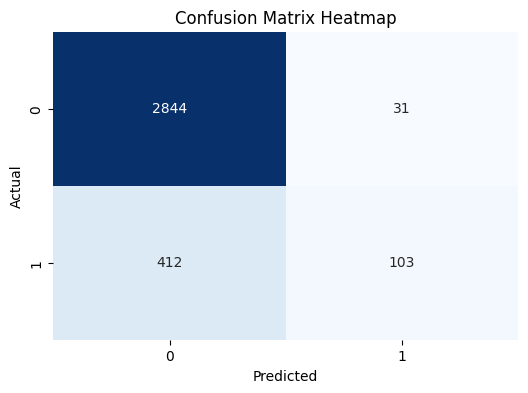

In [ ]:
cm = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8337264150943396
Confusion Matrix:
 [[699  20]
 [121   8]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       719
           1       0.29      0.06      0.10       129

    accuracy                           0.83       848
   macro avg       0.57      0.52      0.51       848
weighted avg       0.77      0.83      0.79       848



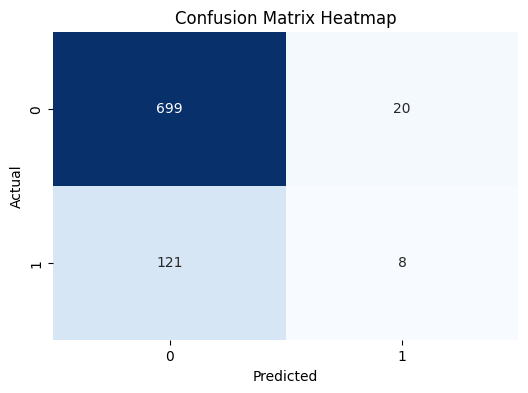

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Naive Bayes

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_train = model.predict(X_train)
print("Accuracy Score:",accuracy_score(y_train, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("Classification Report:\n", classification_report(y_train, y_pred_train))

Accuracy Score: 0.8268436578171091
Confusion Matrix:
 [[2675  200]
 [ 387  128]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90      2875
           1       0.39      0.25      0.30       515

    accuracy                           0.83      3390
   macro avg       0.63      0.59      0.60      3390
weighted avg       0.80      0.83      0.81      3390



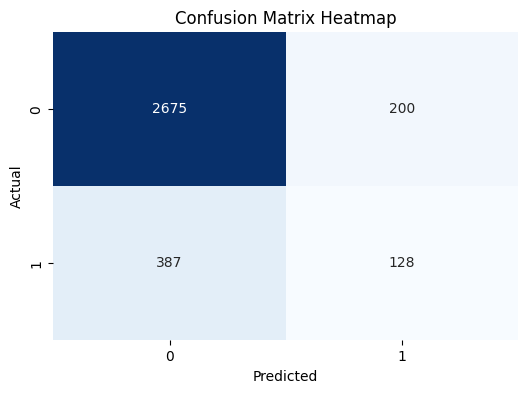

In [ ]:
cm = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8101415094339622
Confusion Matrix:
 [[668  51]
 [110  19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89       719
           1       0.27      0.15      0.19       129

    accuracy                           0.81       848
   macro avg       0.57      0.54      0.54       848
weighted avg       0.77      0.81      0.79       848



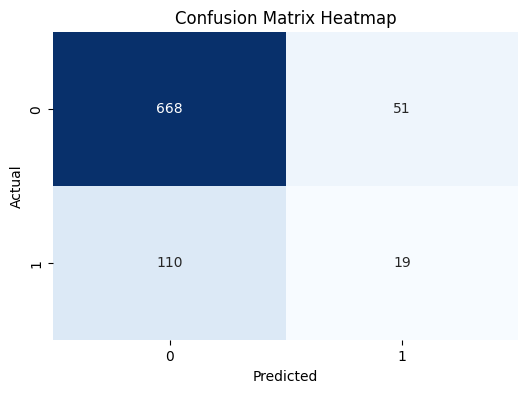

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()